# Computer Vision - Assignment 3
## Multi-scale image representation and scale-invariant blob detection

The goal is to build the complete detector from basic operations: Gaussian kernels, convolution, scale-normalized Laplacian response and 3D non-maximum suppression. I have not used `SimpleBlobDetector`, `blob_log`, SIFT, SURF or ORB anywhere in the notebook.

For the experiment I use a reproducible grayscale test image containing blobs of different sizes and contrast. This keeps the input controlled and makes the effect of scale easy to verify.

In [1]:
import math
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.ndimage import convolve

np.set_printoptions(precision=4, suppress=True)

## Test image

The image below contains nine bright blob-like structures. Their sizes and contrast are deliberately different, and a small amount of noise plus a weak illumination gradient is added so the image is not perfectly ideal.

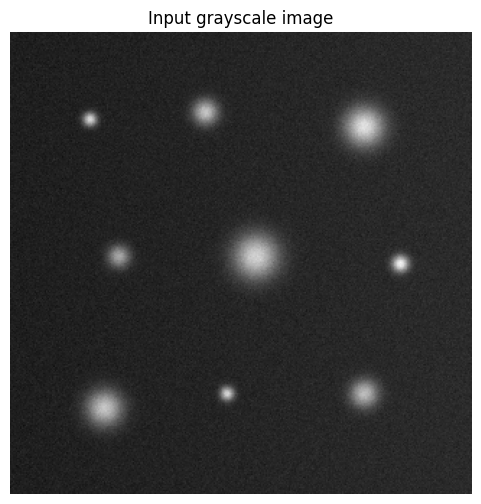

Image shape: (320, 320)
Number of planted blob structures: 9


In [2]:
def make_test_image(size=320, seed=12):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size]
    image = np.full((size, size), 0.12, dtype=np.float64)

    # (x, y, nominal radius, amplitude)
    blob_spec = [
        (55, 60, 5, 0.72),
        (135, 55, 9, 0.62),
        (245, 65, 14, 0.72),
        (75, 155, 8, 0.52),
        (170, 155, 16, 0.68),
        (270, 160, 6, 0.80),
        (65, 260, 13, 0.64),
        (150, 250, 5, 0.70),
        (245, 250, 10, 0.58),
    ]

    for x, y, r, amplitude in blob_spec:
        s = r / 1.5
        image += amplitude * np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * s**2))

    image += 0.05 * (xx / size)
    image += rng.normal(0, 0.018, image.shape)
    return np.clip(image, 0, 1), blob_spec

image, blob_spec = make_test_image()

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Input grayscale image')
plt.axis('off')
plt.show()

print('Image shape:', image.shape)
print('Number of planted blob structures:', len(blob_spec))

## Task 1 - Gaussian Scale Space

For each required scale,

\[
L(x,y,\sigma)=G(x,y,\sigma)*I(x,y)
\]

I form the Gaussian kernel myself and only use a numerical convolution routine to apply it. The kernel is truncated at approximately \(3\sigma\) on both sides and normalized so its coefficients sum to one.

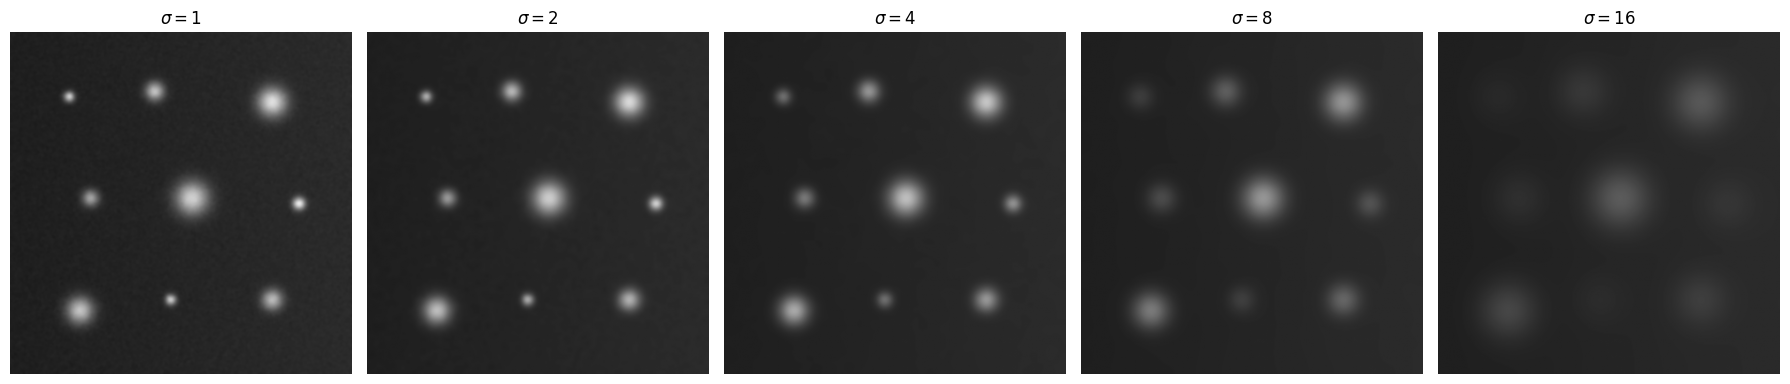

In [3]:
def gaussian_kernel(sigma):
    radius = max(1, int(np.ceil(3 * sigma)))
    a = np.arange(-radius, radius + 1, dtype=np.float64)
    x, y = np.meshgrid(a, a)
    kernel = np.exp(-(x*x + y*y) / (2 * sigma*sigma))
    kernel /= kernel.sum()
    return kernel


def gaussian_smooth(img, sigma):
    kernel = gaussian_kernel(sigma)
    return convolve(img, kernel, mode='reflect')


SIGMAS = [1, 2, 4, 8, 16]
scale_space = [gaussian_smooth(image, sigma) for sigma in SIGMAS]

fig, axes = plt.subplots(1, len(SIGMAS), figsize=(18, 4))
for ax, smoothed, sigma in zip(axes, scale_space, SIGMAS):
    ax.imshow(smoothed, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'$\\sigma={sigma}$')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Observation

At sigma = 1 the small blobs, noise and sharper intensity changes are still visible. As sigma increases, high-frequency noise is removed first and the blob boundaries become softer. At sigma = 8 and 16, small structures almost disappear while the larger structures remain as broad intensity regions. This is the useful part of scale-space: different object sizes become prominent at different smoothing levels instead of forcing one fixed filter size to handle everything.

## Task 2 - Multi-Resolution Representation

For every pyramid step I first smooth the current image and then keep every second sample in both directions. The downsampling is done explicitly with array slicing, so each new level has approximately half the width and half the height of the previous level.

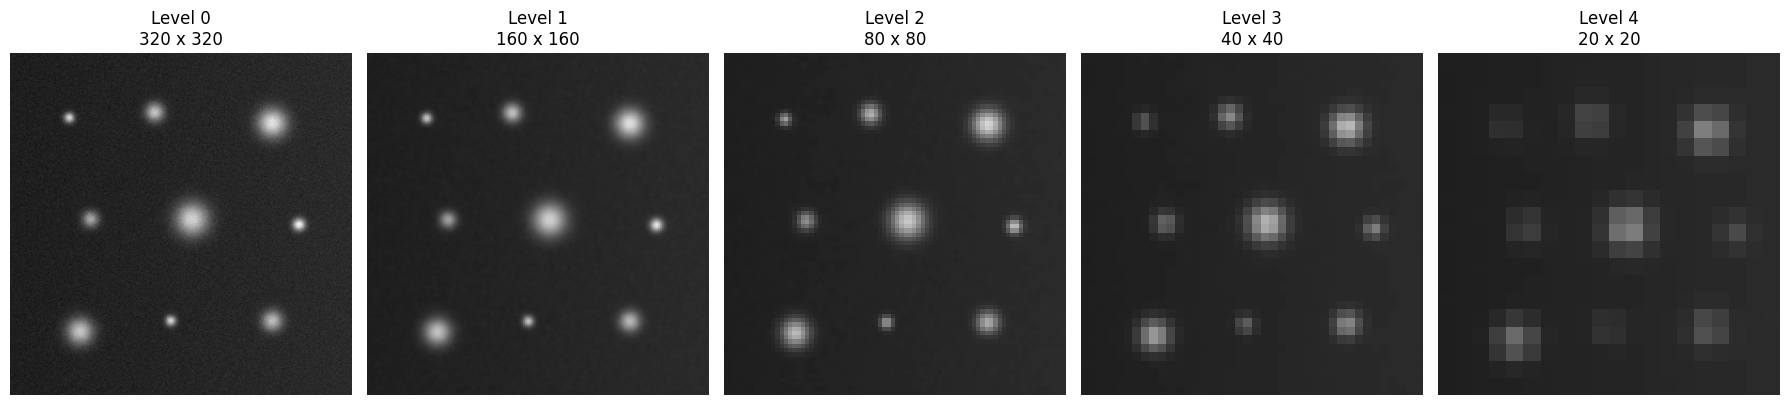

Level 0: 320 x 320 pixels
Level 1: 160 x 160 pixels
Level 2: 80 x 80 pixels
Level 3: 40 x 40 pixels
Level 4: 20 x 20 pixels


In [4]:
def build_gaussian_pyramid(img, levels=5, preblur_sigma=1.0):
    pyramid = [img]
    current = img

    for _ in range(1, levels):
        current = gaussian_smooth(current, preblur_sigma)
        current = current[::2, ::2]
        pyramid.append(current)

    return pyramid


pyramid = build_gaussian_pyramid(image, levels=5)

fig, axes = plt.subplots(1, len(pyramid), figsize=(18, 4))
for i, (ax, level) in enumerate(zip(axes, pyramid)):
    ax.imshow(level, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Level {i}\n{level.shape[1]} x {level.shape[0]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

for i, level in enumerate(pyramid):
    print(f'Level {i}: {level.shape[0]} x {level.shape[1]} pixels')

### Why blur before downsampling?

Downsampling by 2 reduces the Nyquist limit by a factor of 2. Frequencies that were valid in the original image can therefore lie above the new Nyquist frequency. If those frequencies are not suppressed before sampling, they fold into lower frequencies and appear as aliasing. A Gaussian works as a low-pass anti-aliasing filter, so the high-frequency content is attenuated before samples are discarded. In practice this avoids false texture, jagged edges and unstable structures between pyramid levels.

## Task 3 - Scale-Normalized Laplacian-of-Gaussian Response

The required response is

\[
R(x,y,\sigma)=\sigma^2\left|\nabla^2L(x,y,\sigma)\right|.
\]

After Gaussian smoothing I approximate the Laplacian with the discrete 4-neighbour second-derivative kernel. The multiplication by \(\sigma^2\) is then applied explicitly.

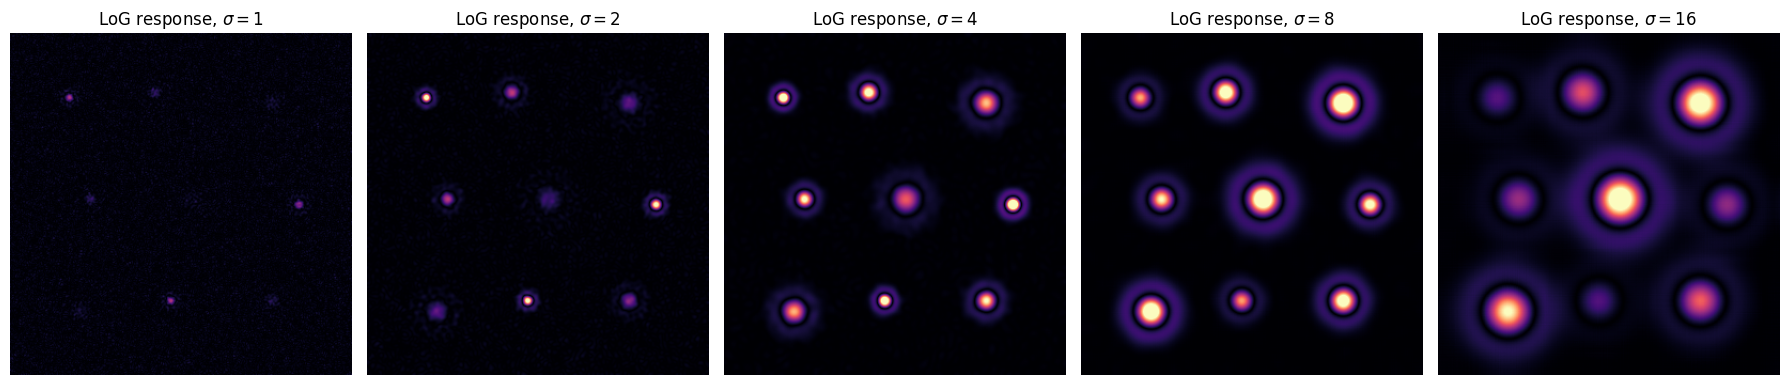

In [5]:
LAPLACIAN_KERNEL = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float64)


def normalized_log_response(img, sigma):
    smoothed = gaussian_smooth(img, sigma)
    lap = convolve(smoothed, LAPLACIAN_KERNEL, mode='reflect')
    return (sigma ** 2) * np.abs(lap)


def build_log_volume(img, sigmas):
    return np.stack([normalized_log_response(img, s) for s in sigmas], axis=0)


log_volume = build_log_volume(image, SIGMAS)
common_vmax = np.percentile(log_volume, 99.7)

fig, axes = plt.subplots(1, len(SIGMAS), figsize=(18, 4))
for i, sigma in enumerate(SIGMAS):
    axes[i].imshow(log_volume[i], cmap='magma', vmin=0, vmax=common_vmax)
    axes[i].set_title(f'LoG response, $\\sigma={sigma}$')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Effect of scale normalization

Without normalization, derivative magnitudes decrease as the Gaussian gets wider, so responses from large scales are not directly comparable with responses from small scales. The factor \(\sigma^2\) compensates for the scale dependence of the second derivative. As a result, the same type of blob can produce a comparable normalized extremum even after the image is resized. The extremum can therefore move along the scale axis instead of simply vanishing because a larger \(\sigma\) was used.

## Task 4 - 3D Scale-Space Extrema Detection

The response maps are stacked into a volume indexed by `(scale, y, x)`. For a candidate at an interior scale, I compare it against the full 3 x 3 x 3 neighborhood after removing the candidate itself. That gives exactly 26 neighbours: 8 at the same scale, 9 below and 9 above.

A relative threshold of 15% of the maximum normalized response is used to reject weak noise responses. The same relative setting is kept for all resized images later.

In [6]:
def nms_3d(response_volume, sigmas, threshold_rel=0.15):
    threshold = threshold_rel * response_volume.max()
    detections = []

    # End scales cannot have a complete 26-neighbourhood.
    for s_idx in range(1, len(sigmas) - 1):
        response = response_volume[s_idx]
        ys, xs = np.where(response > threshold)

        for y, x in zip(ys, xs):
            if y == 0 or x == 0 or y == response.shape[0] - 1 or x == response.shape[1] - 1:
                continue

            value = response_volume[s_idx, y, x]
            neighborhood = response_volume[
                s_idx-1:s_idx+2,
                y-1:y+2,
                x-1:x+2
            ].copy()
            neighborhood[1, 1, 1] = -np.inf

            if value > neighborhood.max():
                detections.append({
                    'x': int(x),
                    'y': int(y),
                    'sigma': float(sigmas[s_idx]),
                    'response': float(value)
                })

    return detections, float(threshold)


detections, detection_threshold = nms_3d(log_volume, SIGMAS, threshold_rel=0.15)

print(f'Absolute response threshold: {detection_threshold:.5f}')
print(f'Number of 3D extrema retained: {len(detections)}')

Absolute response threshold: 0.05971
Number of 3D extrema retained: 9


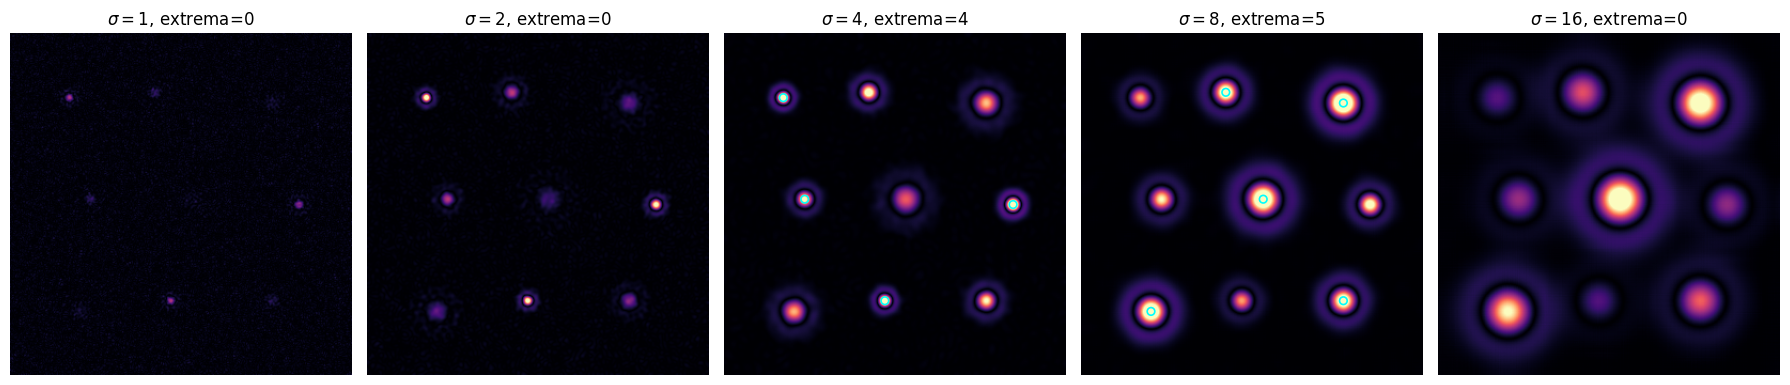

In [7]:
fig, axes = plt.subplots(1, len(SIGMAS), figsize=(18, 4))
for i, sigma in enumerate(SIGMAS):
    axes[i].imshow(log_volume[i], cmap='magma', vmin=0, vmax=common_vmax)

    pts = [d for d in detections if d['sigma'] == sigma]
    if pts:
        axes[i].scatter([d['x'] for d in pts], [d['y'] for d in pts], s=30,
                        facecolors='none', edgecolors='cyan', linewidths=1.2)

    axes[i].set_title(f'$\\sigma={sigma}$, extrema={len(pts)}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Task 5 - Blob Radius Estimation and Visualization

For every accepted extremum, the characteristic radius is estimated by

\[
r \approx \sqrt{2}\,\sigma.
\]

The circles below are drawn directly on the original-resolution image.

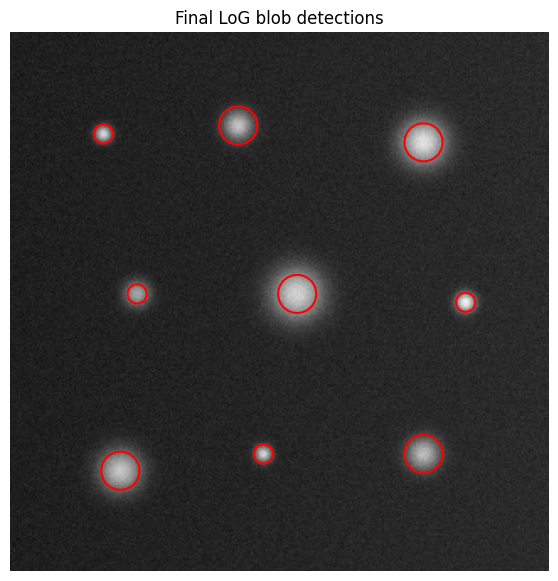

,x,y,sigma,radius,response
0,55,60,4.0,5.66,0.34704
1,75,155,4.0,5.66,0.23987
2,270,160,4.0,5.66,0.39809
3,150,250,4.0,5.66,0.33337
4,135,55,8.0,11.31,0.28829
5,245,65,8.0,11.31,0.35359
6,170,155,8.0,11.31,0.31288
7,245,250,8.0,11.31,0.28206
8,65,260,8.0,11.31,0.32035


In [8]:
def add_radius(detections):
    out = []
    for d in detections:
        q = d.copy()
        q['radius'] = math.sqrt(2) * q['sigma']
        out.append(q)
    return out


detections_with_radius = add_radius(detections)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image, cmap='gray', vmin=0, vmax=1)
for d in detections_with_radius:
    ax.add_patch(Circle((d['x'], d['y']), d['radius'], fill=False,
                        linewidth=1.5, edgecolor='red'))
ax.set_title('Final LoG blob detections')
ax.axis('off')
plt.show()

blob_table = pd.DataFrame(detections_with_radius)
blob_table = blob_table[['x', 'y', 'sigma', 'radius', 'response']]
blob_table['radius'] = blob_table['radius'].round(2)
blob_table['response'] = blob_table['response'].round(5)
blob_table

The detector gives one strong scale-space extremum for each visible blob in the original test image. Smaller blobs are selected at a lower sigma and the larger blobs are selected at a higher sigma, which is the expected scale-selection behaviour.

## Task 6 - Scale Invariance Analysis

I resize the complete test image by factors 1.00, 0.75, 0.50 and 0.25 and run exactly the same detector independently on each version. No detected coordinates from the original image are reused during detection.

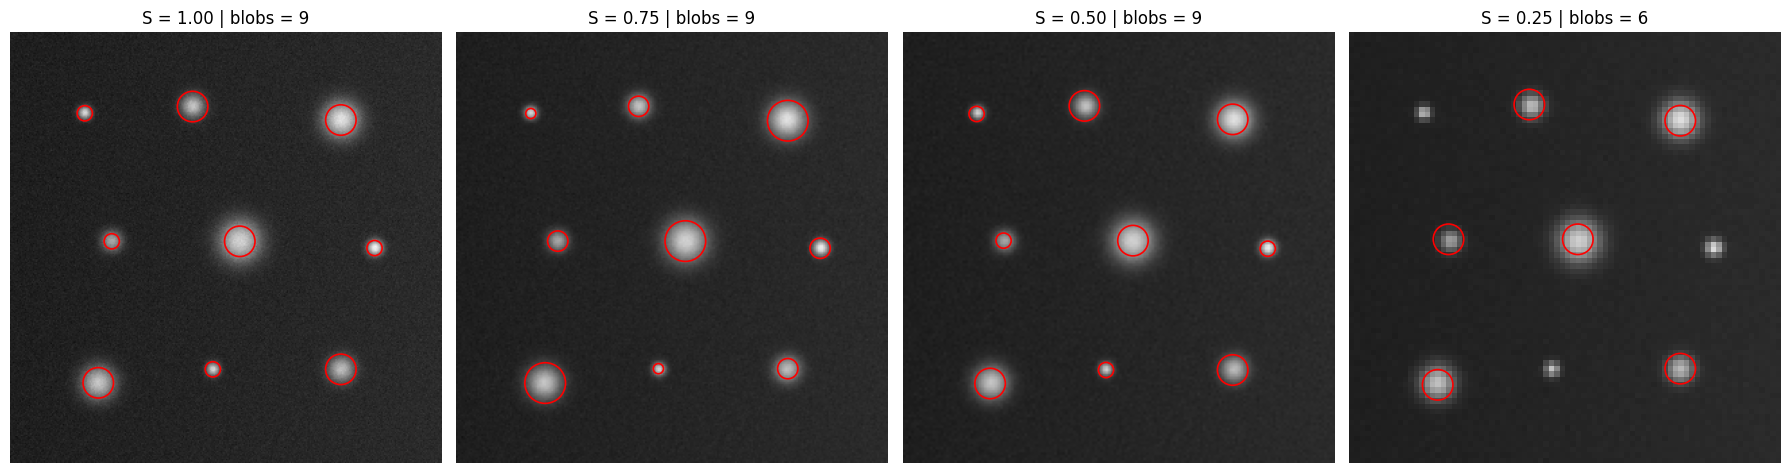

In [9]:
def run_detector(img, sigmas=SIGMAS, threshold_rel=0.15):
    volume = build_log_volume(img, sigmas)
    dets, threshold = nms_3d(volume, sigmas, threshold_rel)
    dets = add_radius(dets)
    return dets, threshold, volume


resize_factors = [1.00, 0.75, 0.50, 0.25]
results = {}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, factor in zip(axes, resize_factors):
    if factor == 1.0:
        variant = image.copy()
    else:
        h, w = image.shape
        new_size = (max(16, int(round(w * factor))), max(16, int(round(h * factor))))
        variant = cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)

    dets, threshold, volume = run_detector(variant)
    results[factor] = {
        'image': variant,
        'detections': dets,
        'threshold': threshold,
        'volume': volume
    }

    ax.imshow(variant, cmap='gray', vmin=0, vmax=1)
    for d in dets:
        ax.add_patch(Circle((d['x'], d['y']), d['radius'], fill=False,
                            linewidth=1.2, edgecolor='red'))
    ax.set_title(f'S = {factor:.2f} | blobs = {len(dets)}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
def match_against_original(reference, candidate, factor):
    # Candidate coordinates are mapped back to the original coordinate system.
    mapped = []
    for d in candidate:
        mapped.append({
            'x': d['x'] / factor,
            'y': d['y'] / factor,
            'radius': d['radius'] / factor
        })

    used = set()
    matched = 0
    distances = []

    for ref in reference:
        choices = []
        for j, cand in enumerate(mapped):
            if j in used:
                continue
            dist = math.hypot(ref['x'] - cand['x'], ref['y'] - cand['y'])
            choices.append((dist, j))

        if not choices:
            continue

        dist, j = min(choices)
        tolerance = max(4.0, 0.8 * ref['radius'])
        if dist <= tolerance:
            used.add(j)
            matched += 1
            distances.append(dist)

    mean_error = float(np.mean(distances)) if distances else np.nan
    return matched, mean_error


reference = results[1.0]['detections']
repeatability_rows = []
for factor in resize_factors:
    matched, error = match_against_original(reference, results[factor]['detections'], factor)
    repeatability_rows.append({
        'Resize factor': factor,
        'Matched original detections': f'{matched}/{len(reference)}',
        'Mean mapped centre error (px)': round(error, 2) if np.isfinite(error) else np.nan
    })

pd.DataFrame(repeatability_rows)

,Resize factor,Matched original detections,Mean mapped centre error (px)
0,1.00,9/9,0.00
1,0.75,9/9,0.58
2,0.50,9/9,0.92
3,0.25,6/9,2.79


### Scale invariance discussion

The detections at 0.75 and 0.50 remain at the same physical blob locations after their coordinates are mapped back to the original image. Their selected sigma and radius become smaller in image pixels, which is exactly what should happen when the image itself becomes smaller.

The 0.25 image is the difficult case. Several of the smallest structures are represented by only a few pixels, and some fall below the available interior scale range or lose enough contrast after area resizing that they no longer form a strong 3D extremum. This is a resolution limit rather than a failure of the normalization idea. A denser set of smaller sigma values would improve this case.

## Task 7 - Quantitative Evaluation and Parameter Discussion

In [11]:
summary_rows = []
variant_names = ['Original', 'Variant 1', 'Variant 2', 'Variant 3']

for name, factor in zip(variant_names, resize_factors):
    dets = results[factor]['detections']
    avg_radius = np.mean([d['radius'] for d in dets]) if dets else np.nan

    summary_rows.append({
        'Image Variant': name,
        'Resize Factor': factor,
        'Detected Blobs': len(dets),
        'Avg. Radius': round(float(avg_radius), 3) if np.isfinite(avg_radius) else np.nan,
        'Detection Threshold': round(results[factor]['threshold'], 5)
    })

summary_table = pd.DataFrame(summary_rows)
summary_table

,Image Variant,Resize Factor,Detected Blobs,Avg. Radius,Detection Threshold
0,Original,1.00,9,8.800,0.05971
1,Variant 1,0.75,9,6.914,0.05393
2,Variant 2,0.50,9,4.400,0.05649
3,Variant 3,0.25,6,2.828,0.05057


### Parameter discussion

**Number of scale octaves.** More octaves allow the detector to cover a wider range of blob sizes. Too few scales make very small or very large structures impossible to select. The cost is additional filtering and a larger 3D response volume.

**Gaussian scale step.** The set \(\{1,2,4,8,16\}\) has a scale ratio of 2, which is simple but quite coarse. A smaller multiplicative step such as \(\sqrt{2}\) gives more accurate characteristic-scale estimates because a blob has a closer available scale, but it also increases computation.

**Downsampling factor.** A factor of 2 is a common compromise. Larger jumps reduce computation quickly but can throw away useful spatial information. Smaller jumps keep more detail but make the pyramid more expensive and more redundant.

**Detection threshold.** A low threshold keeps weak blobs but also admits noise extrema. A high threshold gives cleaner detections but can remove low-contrast objects. I used a relative threshold of 0.15 of the maximum response so the same setting adapts to each resized image instead of depending on one absolute intensity value.

**Input resolution.** Higher resolution gives small structures enough pixels to form a stable spatial extremum and gives the radius estimate finer precision. At very low resolution, smoothing and downsampling merge nearby pixels, so small blobs disappear first. This is visible in the 0.25-scale experiment.

## Bonus - Difference of Gaussians (DoG)

The approximation used is

\[
D(x,y,\sigma)=L(x,y,k\sigma)-L(x,y,\sigma)
\approx (k-1)\sigma^2\nabla^2L(x,y,\sigma).
\]

I use \(k=\sqrt{2}\), calculate both Gaussian images with the same custom Gaussian implementation, and divide the absolute difference by \(k-1\) so the response can be compared with the normalized LoG magnitude.

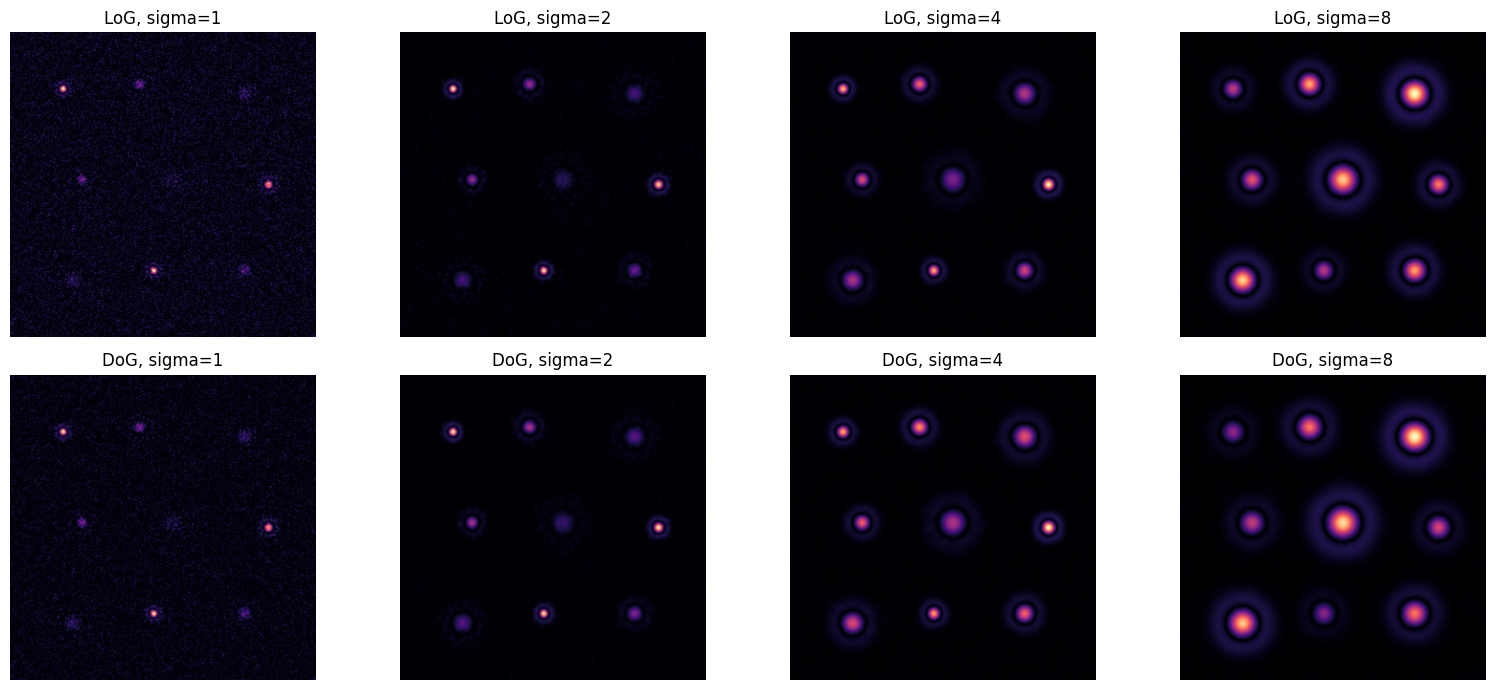

LoG time for 4 scales: 0.3436 s
DoG time for 4 scales: 1.1768 s


,sigma,"LoG strongest peak (x,y)","DoG strongest peak (x,y)",Peak location difference (px),Response correlation
0,1,"(55, 60)","(55, 60)",0.0,0.9560
1,2,"(55, 60)","(55, 60)",0.0,0.9889
2,4,"(270, 160)","(270, 160)",0.0,0.9875
3,8,"(245, 65)","(245, 65)",0.0,0.9827


In [12]:
def normalized_dog_response(img, sigma, k=math.sqrt(2)):
    l1 = gaussian_smooth(img, sigma)
    l2 = gaussian_smooth(img, k * sigma)
    return np.abs(l2 - l1) / (k - 1)


bonus_sigmas = [1, 2, 4, 8]
k = math.sqrt(2)

start = time.perf_counter()
bonus_log = [normalized_log_response(image, s) for s in bonus_sigmas]
log_time = time.perf_counter() - start

start = time.perf_counter()
bonus_dog = [normalized_dog_response(image, s, k) for s in bonus_sigmas]
dog_time = time.perf_counter() - start

fig, axes = plt.subplots(2, len(bonus_sigmas), figsize=(16, 7))
for i, sigma in enumerate(bonus_sigmas):
    axes[0, i].imshow(bonus_log[i], cmap='magma')
    axes[0, i].set_title(f'LoG, sigma={sigma}')
    axes[0, i].axis('off')

    axes[1, i].imshow(bonus_dog[i], cmap='magma')
    axes[1, i].set_title(f'DoG, sigma={sigma}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

comparison = []
for sigma, log_r, dog_r in zip(bonus_sigmas, bonus_log, bonus_dog):
    log_peak = np.unravel_index(np.argmax(log_r), log_r.shape)
    dog_peak = np.unravel_index(np.argmax(dog_r), dog_r.shape)
    peak_error = math.hypot(log_peak[1] - dog_peak[1], log_peak[0] - dog_peak[0])
    corr = np.corrcoef(log_r.ravel(), dog_r.ravel())[0, 1]

    comparison.append({
        'sigma': sigma,
        'LoG strongest peak (x,y)': (int(log_peak[1]), int(log_peak[0])),
        'DoG strongest peak (x,y)': (int(dog_peak[1]), int(dog_peak[0])),
        'Peak location difference (px)': round(peak_error, 3),
        'Response correlation': round(float(corr), 4)
    })

print(f'LoG time for {len(bonus_sigmas)} scales: {log_time:.4f} s')
print(f'DoG time for {len(bonus_sigmas)} scales: {dog_time:.4f} s')
pd.DataFrame(comparison)

### LoG vs DoG

The DoG maps are visually very close to the normalized LoG maps and the response correlations are high. Their strongest feature locations also remain essentially the same, so DoG preserves the important blob-location information in this experiment.

In this direct implementation, DoG can take longer because each requested DoG response computes two Gaussian convolutions, while the LoG path uses one Gaussian convolution followed by a very small 3 x 3 Laplacian convolution. In a practical Gaussian pyramid, neighbouring Gaussian levels are normally computed once and reused. Then a DoG image is only a subtraction between already available levels, which is why DoG is usually computationally attractive in multi-scale detectors.

## Final observation

The experiment shows the full scale-selection pipeline: Gaussian smoothing separates structures by spatial scale, the sigma-squared normalized Laplacian gives comparable responses across those scales, and 3D extrema detection selects both position and characteristic scale. Resizing mainly shifts the selected scale and radius, while very aggressive reduction eventually removes the smallest structures because there is not enough image resolution left to support them.